In [66]:
import pickle

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

periods = ['1221', '0322', '0622', '0922', '1222']   # use yours
nice_label = {'1221':'Dec-2021', '0322':'Mar-2022', '0622':'Jun-2022',
              '0922':'Sep-2022', '1222':'Dec-2022'}

final_rows = []      # “top” table (final values per sector)
# If you also need the returns block, capture it similarly (omitted here for brevity)

for p in periods:
    df = pd.read_excel(f"Data/te-testing-results/benchmark_vs_decarb_final_value_equal_weight_{p}.xlsx")

    # Find the split where the second block (“Benchmark_Return (%)”) starts
    split_row = df.index[df.iloc[:,0].astype(str).str.contains('Benchmark_Return', na=False)]
    split_row = int(split_row[0]) if len(split_row) else len(df)

    top = df.iloc[:split_row].copy()
    top = top.rename(columns={top.columns[0]: "Sector"})
    # keep only the columns we need (adjust names to your sheet)
    top = top[['Sector','Benchmark_Final','Optimised_Final','Difference ($)']]
    top['Period'] = p
    final_rows.append(top)

final_df = pd.concat(final_rows, ignore_index=True)
# Percent difference for heatmap
final_df['Diff_%'] = final_df['Difference ($)'] / final_df['Benchmark_Final']


In [68]:
final_df

,Sector,Benchmark_Final,Optimised_Final,Difference ($),Period,Diff_%
0,Consumer Discretionary,95451.16,92838.60,-2612.56,1221,-0.027371
1,Health Care,108278.23,107533.62,-744.62,1221,-0.006877
2,Utilities,114940.45,111387.24,-3553.21,1221,-0.030913
3,Information Technology,96738.35,96042.41,-695.93,1221,-0.007194
4,Real Estate,105724.43,106590.82,866.39,1221,0.008195
5,Materials,107603.29,104825.25,-2778.04,1221,-0.025817
6,Industrials,106775.58,104626.76,-2148.82,1221,-0.020125
7,Financials,103952.10,102041.76,-1910.34,1221,-0.018377
8,Energy,146500.42,145048.81,-1451.61,1221,-0.009909
9,Communication Services,95364.77,93379.30,-1985.47,1221,-0.020820


What happens if you invest 100k in each sector and then you compare what happens in each sector decarbonised portfolio (fixed weights for the next 3 months) vs the real sector benchmark?

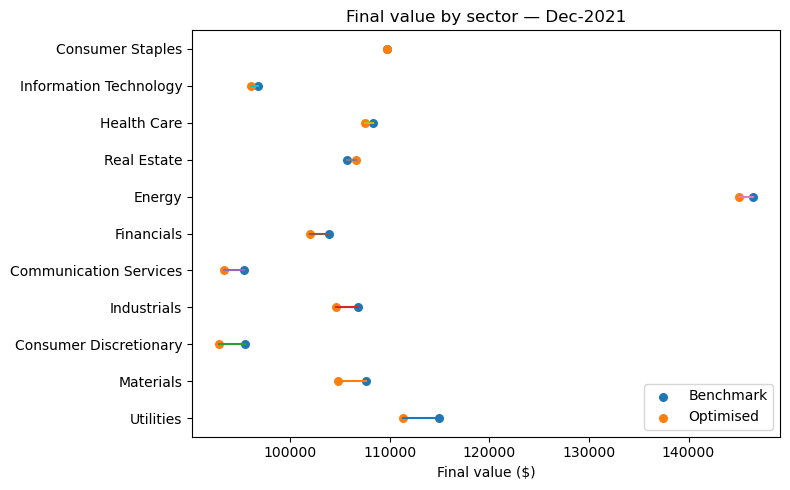

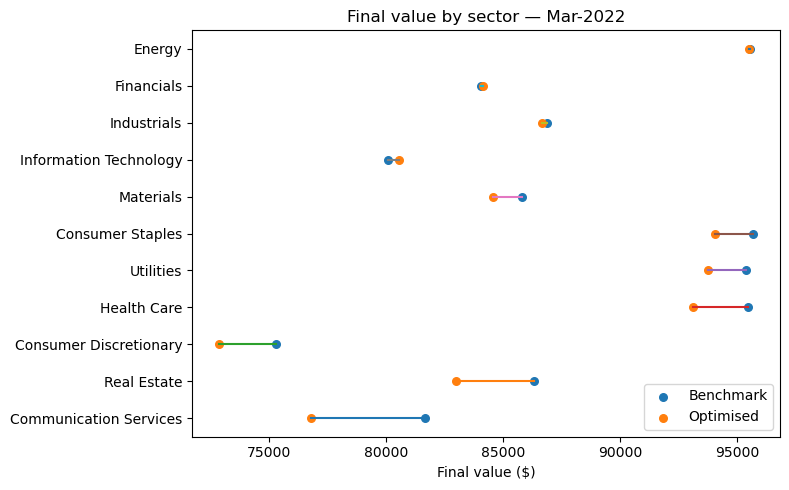

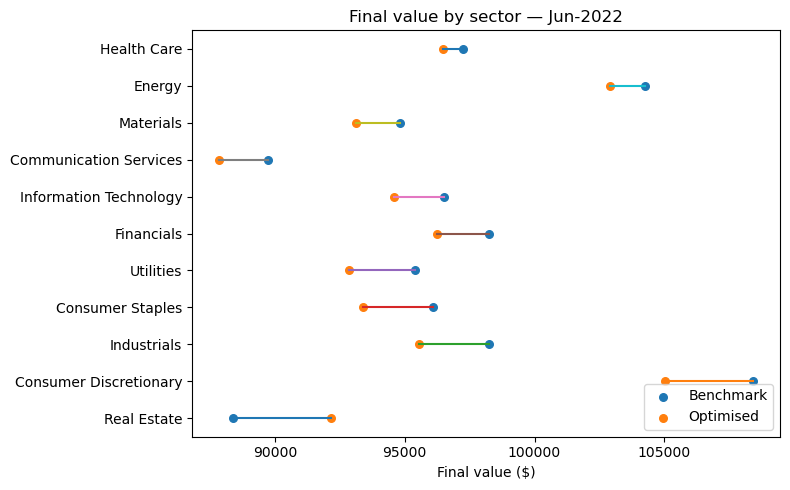

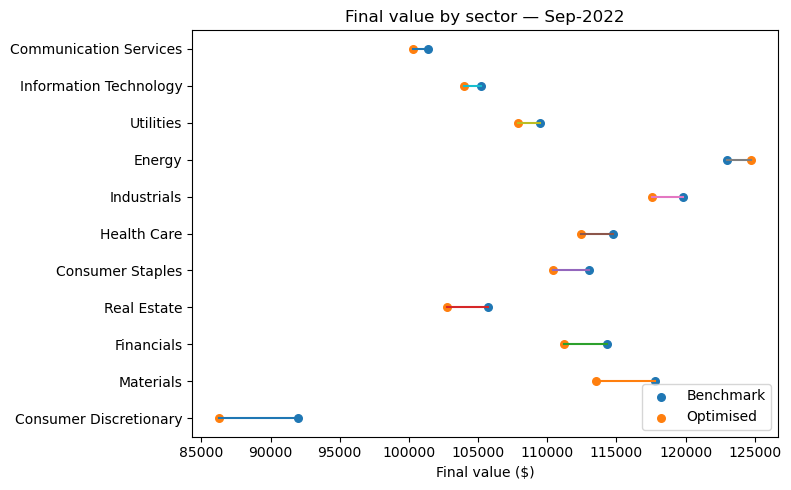

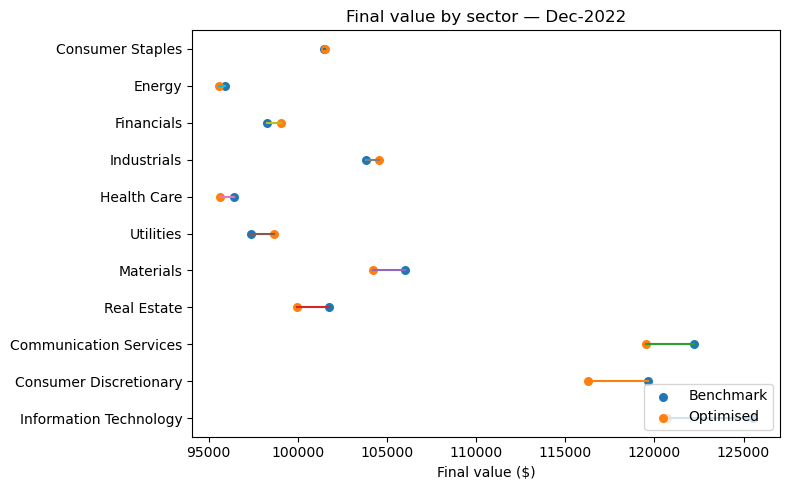

In [69]:
def plot_dumbbell(df_period, period_label=None):
    dfp = df_period.reindex(df_period['Difference ($)'].abs().sort_values(ascending=False).index)

    y = np.arange(len(dfp))

    fig, ax = plt.subplots(figsize=(8, 5))
    # lines between benchmark and optimised
    dfp.reset_index(inplace = True)
    for i, row in dfp.iterrows():

        ax.plot([row['Benchmark_Final'], row['Optimised_Final']], [y[i], y[i]])

    # markers
    ax.scatter(dfp['Benchmark_Final'], y, label='Benchmark', s=30)
    ax.scatter(dfp['Optimised_Final'], y, label='Optimised', s=30)

    ax.set_yticks(y)
    ax.set_yticklabels(dfp['Sector'])
    ax.set_xlabel('Final value ($)')
    ax.set_title(f'Final value by sector — {period_label}')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# Example: draw for one period
for p in periods:

    plot_dumbbell(final_df[final_df['Period']==p], nice_label.get(p, p))


TE per sector:

In [3]:
import pandas as pd
R = pd.read_excel("Data/sector_log_returns_comp_1222_without_ceg_ogn.xlsx", sheet_name="Health Care")
print(R)


         Date       ABT      AMGN       BAX       BDX       BIO       BSX  \
0  2021-01-15  0.125157  0.048848 -0.043427  0.045202 -0.015856 -0.014288   
1  2021-02-15 -0.031313 -0.063427  0.014256 -0.082123  0.018528  0.090064   
2  2021-03-15  0.000501  0.100945  0.082130  0.011638 -0.023070 -0.003358   
3  2021-04-15  0.005666 -0.037552  0.015880  0.023011  0.098239  0.120510   
4  2021-05-15 -0.028980 -0.000112 -0.042554 -0.028206 -0.045054 -0.024377   
5  2021-06-15 -0.006192  0.024125 -0.016487  0.008831  0.067277  0.004923   
6  2021-07-15  0.046439 -0.009108 -0.039917  0.050357  0.137839  0.064305   
7  2021-08-15  0.043589 -0.060889 -0.014717 -0.015962  0.084631 -0.009917   
8  2021-09-15 -0.067428 -0.058806  0.057378 -0.020414 -0.075960 -0.039761   
9  2021-10-15  0.091027 -0.027074 -0.018445 -0.025670  0.063281 -0.006010   
10 2021-11-15 -0.024505 -0.031512 -0.057204 -0.010279 -0.053609 -0.124792   
11 2021-12-15  0.112459  0.123265  0.144483  0.062249  0.003142  0.109607   

In [80]:
import pickle
import pandas as pd
import numpy as np

# Load sector benchmark weights
with open('Data/optimal_portfolios_1222_without_ceg_ogn.pkl', 'rb') as file:
    data = pickle.load(file)

# Compute volatility per sector
sector_vols = []
for sector_name in data.keys():
    R = pd.read_excel("Data/sector_log_returns_comp_1222_without_ceg_ogn.xlsx", sheet_name=sector_name)
    R_clean = R.drop(columns=['Date']).dropna()
    
    w_last = data[sector_name]['w_b_vec']  # last-period benchmark weights
    sector_bench_return = (R_clean * w_last).sum(axis=1)
    
    # Annualized volatility
    sector_vol = np.std(sector_bench_return) * np.sqrt(12)
    
    sector_vols.append({'Sector': sector_name, 'Sector Volatility': sector_vol})

# Create a DataFrame
vol_df = pd.DataFrame(sector_vols)

# --- keep your existing part ---
files = {
    "te_1221.xlsx": "TE Dec 21",
    "te_0322.xlsx": "TE Mar 22",
    "te_0622.xlsx": "TE Jun 22",
    "te_0922.xlsx": "TE Sep 22",
    "te_1222.xlsx": "TE Dec 22"
}

def traffic_light(te):
    if te <= 0.025:
        return f"{te:.1%} 🟢"
    elif te <= 0.03:
        return f"{te:.1%} 🟡"
    else:
        return f"{te:.1%} 🔴"

# Store both formatted and raw TE
dfs = []
for f, label in files.items():
    df = pd.read_excel("Data/te-testing-results/" + f)
    df = df.rename(columns={"Unnamed: 0": "Sector"})
    df[label + "_raw"] = df["Annualised_TE"]  # keep raw value
    df[label] = df["Annualised_TE"].apply(traffic_light)
    dfs.append(df[["Sector", label, label + "_raw"]])

# Merge all
final_df = dfs[0]
for df in dfs[1:]:
    final_df = final_df.merge(df, on="Sector")

# --- Count greens, yellows, reds per sector ---
def classify(te):
    if te <= 0.025:
        return "green"
    elif te <= 0.03:
        return "yellow"
    else:
        return "red"

color_counts = []
for _, row in final_df.iterrows():
    raw_cols = [c for c in final_df.columns if c.endswith("_raw")]
    colors = [classify(row[c]) for c in raw_cols]
    counts = {c: colors.count(c) for c in ["green", "yellow", "red"]}
    color_counts.append(counts)

color_df = pd.DataFrame(color_counts, index=final_df["Sector"])

carbon_df = pd.DataFrame([
    {"Sector": sector_name,
     "% Carbon Reduction": data[sector_name]['% carbon reduction']}
    for sector_name in data.keys()
])

# Merge sector volatility and carbon reduction
final_df = final_df.merge(vol_df, on="Sector", how="left")
final_df = final_df.merge(carbon_df, on="Sector", how="left")

# Merge counts into table

final_df = final_df.set_index("Sector")
final_df = final_df.merge(color_df, on="Sector", how="left")

# --- Sort by #greens (desc), then #yellows (desc), then #reds (asc) ---
final_df = final_df.sort_values(by=["green", "yellow", "red"], ascending=[False, False, True])

pretty_cols = [c for c in final_df.columns if not c.endswith("_raw")]

# Optional: format
final_df["Sector Volatility"] = final_df["Sector Volatility"].apply(lambda x: f"{x:.1%}")
final_df["% Carbon Reduction"] = final_df["% Carbon Reduction"].apply(lambda x: f"{x:.1f}%")

# Display final, clean table
print(final_df[pretty_cols])



                       TE Dec 21 TE Mar 22 TE Jun 22 TE Sep 22 TE Dec 22  \
Sector                                                                     
Energy                    1.4% 🟢    2.8% 🟡    1.9% 🟢    1.4% 🟢    1.8% 🟢   
Consumer Staples          2.2% 🟢    2.9% 🟡    2.1% 🟢    2.2% 🟢    1.9% 🟢   
Real Estate               1.4% 🟢    5.3% 🔴    2.3% 🟢    4.1% 🔴    2.4% 🟢   
Health Care               2.8% 🟡    2.9% 🟡    2.5% 🟡    2.2% 🟢    2.2% 🟢   
Materials                 3.0% 🟡    2.7% 🟡    2.4% 🟢    3.0% 🔴    2.4% 🟢   
Consumer Discretionary    2.0% 🟢    3.7% 🔴    2.3% 🟢    5.1% 🔴    2.7% 🟡   
Financials                1.9% 🟢    2.1% 🟢    2.9% 🟡    3.1% 🔴    5.5% 🔴   
Communication Services    4.0% 🔴    4.7% 🔴    1.6% 🟢    2.9% 🟡    2.4% 🟢   
Information Technology    3.1% 🔴    2.3% 🟢    2.3% 🟢    3.1% 🔴    3.0% 🔴   
Utilities                 2.6% 🟡    2.6% 🟡    2.7% 🟡    2.5% 🟡    2.4% 🟢   
Industrials               2.9% 🟡    3.1% 🔴    2.4% 🟢    2.9% 🟡    2.6% 🟡   

           

In [73]:
data

{'Consumer Discretionary': {'w_b_vec': array([0.26144158, 0.01286412, 0.00563679, 0.01222142, 0.00270964,
         0.01434662, 0.0071228 , 0.00415897, 0.00723908, 0.00776096,
         0.00250792, 0.10965114, 0.00625309, 0.00245699, 0.04081673,
         0.00327321, 0.06540087, 0.00176235, 0.01521046, 0.00475396,
         0.04908383, 0.00364706, 0.01196236, 0.00295693, 0.00378962,
         0.00306337, 0.03930301, 0.00796061, 0.00305404, 0.00258053,
         0.00200916, 0.00484491, 0.00287124, 0.03078346, 0.00388555,
         0.00518044, 0.0122389 , 0.00803486, 0.0044618 , 0.00138018,
         0.11231182, 0.01672109, 0.01550842, 0.00404845, 0.00809416,
         0.00162135, 0.02547184, 0.00328556, 0.00242654, 0.00369731,
         0.00468678, 0.01144613]),
  'w_opt': array([2.69023208e-01, 2.78286992e-02, 3.42942187e-08, 7.62739678e-10,
         3.34428289e-02, 1.24580724e-09, 1.98139212e-02, 1.16821766e-02,
         2.12712306e-02, 1.35669883e-02, 8.03490575e-03, 1.35204114e-01,
         1

In [ ]:
# Merge sector volatility into your TE table
final_df = final_df.merge(vol_df, on="Sector", how="left")

# Optional: sort by volatility or include it in display
pretty_cols = [c for c in final_df.columns if not c.endswith("_raw")]

# Display final table
print(final_df[pretty_cols])


                    Sector TE Dec 21 TE Mar 22 TE Jun 22 TE Sep 22 TE Dec 22  \
0                   Energy    1.4% 🟢    2.8% 🟡    1.9% 🟢    1.4% 🟢    1.8% 🟢   
1         Consumer Staples    2.2% 🟢    2.9% 🟡    2.1% 🟢    2.2% 🟢    1.9% 🟢   
2              Real Estate    1.4% 🟢    5.3% 🔴    2.3% 🟢    4.1% 🔴    2.4% 🟢   
3              Health Care    2.8% 🟡    2.9% 🟡    2.5% 🟡    2.2% 🟢    2.2% 🟢   
4                Materials    3.0% 🟡    2.7% 🟡    2.4% 🟢    3.0% 🔴    2.4% 🟢   
5   Consumer Discretionary    2.0% 🟢    3.7% 🔴    2.3% 🟢    5.1% 🔴    2.7% 🟡   
6               Financials    1.9% 🟢    2.1% 🟢    2.9% 🟡    3.1% 🔴    5.5% 🔴   
7   Communication Services    4.0% 🔴    4.7% 🔴    1.6% 🟢    2.9% 🟡    2.4% 🟢   
8   Information Technology    3.1% 🔴    2.3% 🟢    2.3% 🟢    3.1% 🔴    3.0% 🔴   
9                Utilities    2.6% 🟡    2.6% 🟡    2.7% 🟡    2.5% 🟡    2.4% 🟢   
10             Industrials    2.9% 🟡    3.1% 🔴    2.4% 🟢    2.9% 🟡    2.6% 🟡   

    green  yellow  red  Sector Volatili

Results of investing 100k into the decarbonised portfolio (by aggregating the 11 single portfolio and weighting them based on the sector weights in the original benchmark) vs the real S&P 500 benchmark:

In [87]:
import pandas as pd
import numpy as np

# Parameters
TE_TARGET_ANNUAL = 0.02
TE_TARGET_Q = TE_TARGET_ANNUAL / np.sqrt(4)

# Files for all testing periods
periods = ["1221", "0322", "0622", "0922", "1222"]

records = []

for p in periods:
    print(f"Processing period {p} ...")

    # --- Load TE file ---
    te_path = f"Data/te-testing-results/te_{p}.xlsx"
    te_df = pd.read_excel(te_path).rename(columns={"Unnamed: 0": "Sector"})
    te_df["TE_quarterly"] = te_df["Annualised_TE"] / np.sqrt(4)

    # --- Load realized returns ---
    ret_path = f"Data/te-testing-results/quarterly_ret_{p}.xlsx"
    ret_df = pd.read_excel(ret_path)

    # --- Merge TE and returns ---
    merged = pd.merge(te_df, ret_df, on="Sector", how="inner")

    # --- Compute metrics ---
    merged["Return_Diff"] = merged["Return_Decarb_Q"] - merged["Return_Bench_Q"]
    merged["TE_Deviation"] = (merged["TE_quarterly"] - TE_TARGET_Q).abs()
    merged["Efficiency"] = -merged["Return_Diff"] / merged["TE_quarterly"]

    merged["Period"] = p
    records.append(merged[["Sector", "Period", "TE_quarterly", "TE_Deviation", "Efficiency"]])

# Combine all periods
robust_df = pd.concat(records, ignore_index=True)

# --- Aggregate per sector ---
robust_summary = robust_df.groupby("Sector").agg({
    "TE_quarterly": "mean",
    "TE_Deviation": "mean",
    "Efficiency": "mean"
}).reset_index()

# Rename for clarity
robust_summary = robust_summary.rename(columns={
    "TE_quarterly": "Avg_Realized_TE",
    "TE_Deviation": "Avg_TE_Deviation",
    "Efficiency": "Avg_Efficiency"
})

# Save for later plotting
robust_summary.to_excel("Data/te-testing-results/robustness_summary.xlsx", index=False)

print("✅ Robustness summary computed.")
print(robust_summary.round(4).sort_values(by= 'Avg_Realized_TE', ascending= False))


Processing period 1221 ...
Processing period 0322 ...
Processing period 0622 ...
Processing period 0922 ...
Processing period 1222 ...
✅ Robustness summary computed.
                    Sector  Avg_Realized_TE  Avg_TE_Deviation  Avg_Efficiency
4               Financials           0.0152            0.0058          0.8132
0   Communication Services           0.0150            0.0057          0.9191
7   Information Technology           0.0146            0.0046          0.8796
1   Consumer Discretionary           0.0142            0.0042          1.7604
6              Industrials           0.0138            0.0038          0.6808
8                Materials           0.0138            0.0038          1.3221
10               Utilities           0.0129            0.0029          0.4764
5              Health Care           0.0125            0.0025          0.5627
9              Real Estate           0.0117            0.0040         -0.2048
2         Consumer Staples           0.0107           

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_5586/2024994342.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  robust_df = pd.concat(records, ignore_index=True)


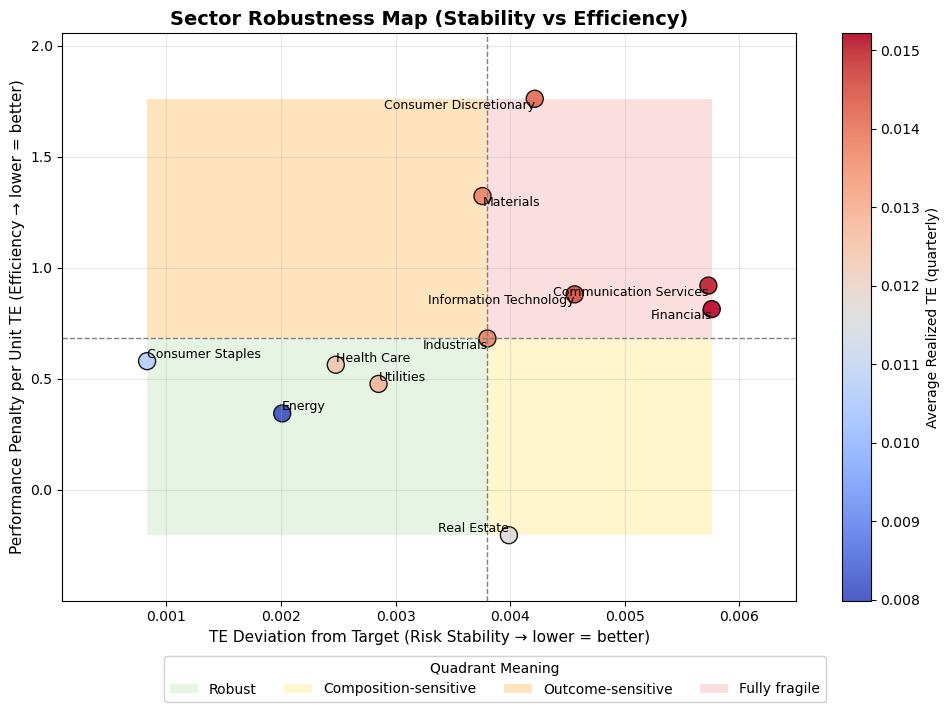

In [85]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

df = robust_summary.copy()

x = df["Avg_TE_Deviation"].values
y = df["Avg_Efficiency"].values
sectors = df["Sector"].values

# Median-based quadrants
x_med = np.nanmedian(x)
y_med = np.nanmedian(y)

# --- Figure setup ---
fig, ax = plt.subplots(figsize=(10, 7))

# Shaded quadrants (correct scaling)
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
x_pad = (x_max - x_min) * 0.15
y_pad = (y_max - y_min) * 0.15

ax.set_xlim(x_min - x_pad, x_max + x_pad)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

quadrants = [
    (x_min, x_med, y_min, y_med, "#B7E1B0", "Robust"),
    (x_med, x_max, y_min, y_med, "#FFE873", "Composition-sensitive"),
    (x_min, x_med, y_med, y_max, "#FFB347", "Outcome-sensitive"),
    (x_med, x_max, y_med, y_max, "#F4A6A6", "Fully fragile")
]

for (x0, x1, y0, y1, color, label) in quadrants:
    rect = patches.Rectangle((x0, y0), x1-x0, y1-y0,
                             facecolor=color, alpha=0.35, label=label, zorder=0)
    ax.add_patch(rect)

# --- Scatter plot ---
sc = ax.scatter(
    x, y,
    s=150,
    c=df["Avg_Realized_TE"],
    cmap="coolwarm",
    edgecolor="k",
    alpha=0.9
)

# --- Labels ---
for i, sector in enumerate(sectors):
    ha = 'left' if x[i] < x_med else 'right'
    va = 'bottom' if y[i] < y_med else 'top'
    ax.text(x[i], y[i], sector, fontsize=9, ha=ha, va=va)

# --- Lines & aesthetics ---
ax.axvline(x=x_med, color="gray", linestyle="--", linewidth=1)
ax.axhline(y=y_med, color="gray", linestyle="--", linewidth=1)

ax.set_title("Sector Robustness Map (Stability vs Efficiency)", fontsize=14, fontweight="bold")
ax.set_xlabel("TE Deviation from Target (Risk Stability → lower = better)", fontsize=11)
ax.set_ylabel("Performance Penalty per Unit TE (Efficiency → lower = better)", fontsize=11)

# --- Colorbar ---
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Average Realized TE (quarterly)", fontsize=10)

# --- Legend below ---
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
legend = fig.legend(by_label.values(), by_label.keys(),
                    title="Quadrant Meaning",
                    loc="lower center",
                    bbox_to_anchor=(0.5, -0.02),
                    ncol=4,
                    frameon=True)
legend.get_frame().set_alpha(0.9)

ax.grid(alpha=0.3)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [11]:
import pandas as pd
import glob

# Map periods to nice labels
labels = {
    "1221": "Dec 21 – Mar 22",
    "0322": "Mar 22 – Jun 22",
    "0622": "Jun 22 – Sep 22",
    "0922": "Sep 22 – Dec 22",
    "1222": "Dec 22 – Mar 23"
}

# Collect results
results = []

for file in glob.glob("Data/te-testing-results/benchmark_vs_decarb_final_value_proportional_*.xlsx"):
    period = file.split("_")[-1].split(".")[0]  # e.g. "0922"
    df = pd.read_excel(file, index_col=0)

    benchmark_val = df.loc["Benchmark", "Final value ($)"]
    decarb_val = df.loc["Decarbonised", "Final value ($)"]
    diff_val = df.loc["Difference", "Final value ($)"]

    benchmark_ret = df.loc["Benchmark", "Return (%)"]
    decarb_ret = df.loc["Decarbonised", "Return (%)"]
    diff_ret = df.loc["Difference", "Return (%)"]

    results.append({
        "Period": labels.get(period, period),
        "Benchmark ($)": benchmark_val,
        "Decarb ($)": decarb_val,
        "Difference ($)": diff_val,
        "Benchmark (%)": benchmark_ret,
        "Decarb (%)": decarb_ret,
        "Difference (%)": diff_ret
    })

# Define correct chronological order
period_order = [
    "Dec 21 – Mar 22",
    "Mar 22 – Jun 22",
    "Jun 22 – Sep 22",
    "Sep 22 – Dec 22",
    "Dec 22 – Mar 23"
]

# Turn Period into categorical with that order
summary_df.index = pd.CategoricalIndex(summary_df.index, categories=period_order, ordered=True)

# Sort by this order
summary_df = summary_df.sort_index()



# Format for presentation (1 decimal for %, round $ to 0)
summary_df_display = summary_df.copy()
summary_df_display[["Benchmark ($)", "Decarb ($)", "Difference ($)"]] = summary_df_display[["Benchmark ($)", "Decarb ($)", "Difference ($)"]].round(0).astype(int)
summary_df_display[["Benchmark (%)", "Decarb (%)", "Difference (%)"]] = (summary_df_display[["Benchmark (%)", "Decarb (%)", "Difference (%)"]] * 100).round(1)

summary_df_display = summary_df.copy()

# Format $ columns as whole numbers
summary_df_display[["Benchmark ($)", "Decarb ($)", "Difference ($)"]] = \
    summary_df_display[["Benchmark ($)", "Decarb ($)", "Difference ($)"]].round(0).astype(int)

# Format % columns with 1 decimal place
summary_df_display[["Benchmark (%)", "Decarb (%)", "Difference (%)"]] = \
    summary_df_display[["Benchmark (%)", "Decarb (%)", "Difference (%)"]].round(1)

print(summary_df_display)



NameError: name 'summary_df' is not defined